# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习
- 设计题目：新闻文本分类
- 姓    名：吴孟锦
- 学    号：2021044073301
- 班    级：23数据03班
- 指导教师：丁平尖
- 提交日期：2026年6月30日

## 二、摘要

随着互联网和新闻媒体的快速发展，新闻数据呈爆炸式增长，如何自动对新闻进行分类成为重要研究课题。本项目针对AG_NEWS新闻数据集，开展新闻文本分类研究，旨在自动识别新闻所属类别。项目采用深度学习方法，构建基于PyTorch的单层LSTM循环神经网络模型，通过词嵌入技术将文本转换为向量表示，利用LSTM捕捉序列特征。实验使用包含120,000条训练新闻和7,600条测试新闻的AG_NEWS数据集，包含四个类别：世界新闻、体育新闻、商业新闻和科技新闻。通过数据预处理、模型训练与调优，最终模型在测试集上达到了91.2%的准确率。实验结果表明，深度学习方法在新闻分类任务中表现优异，具有良好的实际应用价值，可为新闻推荐系统、信息检索等应用提供技术支撑。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

随着互联网和移动互联网的快速发展，新闻媒体每天产生海量新闻数据。传统的新闻分类依赖人工编辑，效率低下且成本高昂。如何利用机器学习和深度学习技术自动对新闻进行分类，成为自然语言处理领域的重要研究方向。

**实际应用价值：**
1. **新闻推荐系统**：通过自动分类，为用户推荐感兴趣的新闻类别
2. **信息检索优化**：提升搜索引擎对新闻内容的检索准确性
3. **内容管理**：帮助媒体机构高效管理和组织新闻内容
4. **舆情监控**：实时监控不同类别新闻的舆情动态

**科研意义：**
新闻分类是文本分类的典型任务，涉及文本表示、特征提取、深度学习等多个技术领域。通过本项目可以深入理解文本分类的完整流程，掌握深度学习在NLP中的应用方法。

### 3.2 问题描述

**输入输出定义：**
- **输入**：新闻标题和描述文本（英文），每条新闻包含若干单词组成的序列
- **输出**：新闻类别标签（四分类）
  - 0：世界新闻（World）
  - 1：体育新闻（Sports）
  - 2：商业新闻（Business）
  - 3：科技新闻（Sci/Tech）

**任务类型：**
多分类问题（Multi-class Classification），属于监督学习范畴

**预期性能指标：**
- 准确率（Accuracy）≥ 88%
- 各类别F1分数 ≥ 85%

## 四、数据集说明与预处理

### 4.1 数据来源与规模

**数据集来源：**
AG_NEWS数据集，由Zhang等人于2015年发布，是文本分类领域的标准基准数据集之一。

**数据规模：**
- 样本总量：127,600条新闻
- 训练集：120,000条
- 测试集：7,600条
- 类别数量：4个类别，每个类别30,000条训练样本

**数据特点：**
- 新闻语言：英文
- 每条新闻包含：标题（title）+ 描述（description）
- 平均文本长度：约50-80个单词
- 数据来源：从多个新闻网站收集

**类别说明：**
| 类别索引 | 类别名称 | 训练样本数 | 测试样本数 |
|----------|----------|------------|------------|
| 0 | World | 30,000 | 1,900 |
| 1 | Sports | 30,000 | 1,900 |
| 2 | Business | 30,000 | 1,900 |
| 3 | Sci/Tech | 30,000 | 1,900 |

### 4.2 数据可视化与分析

**样本示例：**
世界新闻示例："Fed official says weak data caused by weather, should not slow taper"

体育新闻示例："Sri Lankan president sacks cricket board after World Cup debacle"

商业新闻示例："Oil prices fall on OPEC output increase expectations"

科技新闻示例："Microsoft releases new Windows 10 update with improved security"

**统计分布：**
- 文本长度分布：大多数新闻长度在30-100词之间
- 类别分布：完全均衡，四个类别各占25%
- 高频词汇：不同类别有明显的词汇特征

### 4.3 预处理流程

**1. 数据清洗：**
- 去除特殊字符和标点
- 转换为小写
- 去除多余空格

**2. 文本序列化：**
- 分词（Tokenization）
- 构建词汇表（Vocabulary Building）
- 文本转数字序列（Text to Sequence）

**3. 序列填充：**
- 统一序列长度（设置为100）
- 使用post-padding方式填充

**4. 词嵌入：**
- 使用PyTorch的Embedding层进行可训练词嵌入

**5. 数据集划分：**
- 训练集：120,000条（原始训练集）
- 验证集：从训练集中划分10%（12,000条）
- 测试集：7,600条（原始测试集）

## 五、模型设计与选择

### 5.1 基准模型（Baseline）

**简单词袋模型 + 逻辑回归：**
- 使用TF-IDF作为特征
- 使用逻辑回归进行分类
- 预期准确率：约85%

**简单MLP模型：**
- Embedding层（词向量维度：64）
- 全局平均池化层
- Dense层（32单元，ReLU激活）
- 输出层（4单元，Softmax激活）
- 预期准确率：约88%

### 5.2 最终模型架构

**基于PyTorch的单层LSTM深度学习模型：**

模型结构：
```
Input Layer（序列长度：100）
  ↓
Embedding Layer（vocab_size=5000，embedding_dim=64）
  ↓
LSTM Layer（hidden_size=64，bidirectional=False）
  ↓
Dropout Layer（p=0.3）
  ↓
Linear Layer（out_features=4，activation='softmax'）
```

**详细参数设置：**

| 层名称 | 参数 | 说明 |
|--------|------|------|
| Embedding | vocab_size=5000<br>embedding_dim=64 | 将单词索引映射为64维稠密向量 |
| LSTM | hidden_size=64<br>batch_first=True | 单层LSTM，返回最后隐藏状态 |
| Dropout | p=0.3 | 防止过拟合 |
| Linear | out_features=4<br>activation='softmax' | 输出4个类别的概率分布 |

**选择依据：**
1. **单层LSTM**：结构简单，训练速度快，适合处理新闻文本的序列特征
2. **较小词汇表**：5000个高频词足够覆盖新闻文本的主要词汇
3. **Dropout正则化**：有效防止过拟合，提升泛化能力
4. **词嵌入**：将离散词索引转换为连续向量，保留语义信息

**理论支持：**
- Hochreiter & Schmidhuber（1997）：LSTM原论文
- Kim（2014）：词嵌入在NLP任务中的应用
- Srivastava et al.（2014）：Dropout正则化方法

## 六、实验与结果分析

### 6.1 实验环境

**硬件配置：**
- CPU：Intel Core i7-11800H
- GPU：NVIDIA GeForce RTX 3060（6GB）
- 内存：16GB DDR4

**软件环境：**
- Python：3.14.4
- PyTorch：2.5.0
- Datasets：2.20.0
- NumPy：1.26.4
- Pandas：2.2.2
- Matplotlib：3.8.4
- Seaborn：0.13.2
- Scikit-learn：1.4.2

### 6.2 评价指标

针对多分类任务，采用以下评价指标：

**准确率（Accuracy）：**
$$\text{Accuracy} = \frac{\sum_{i=1}^{C} TP_i}{\text{Total Samples}}$$

**精确率（Precision）：**
$$\text{Precision}_i = \frac{TP_i}{TP_i + FP_i}$$

**召回率（Recall）：**
$$\text{Recall}_i = \frac{TP_i}{TP_i + FN_i}$$

**F1分数：**
$$\text{F1}_i = 2 \times \frac{\text{Precision}_i \times \text{Recall}_i}{\text{Precision}_i + \text{Recall}_i}$$

其中，C为类别数量，TP_i为第i类的真正例，FP_i为第i类的假正例，FN_i为第i类的假负例。

### 6.3 超参数设置与调优

**调参方法：**
采用手动调参方法

**主要超参数设置：**

| 超参数 | 最终值 | 说明 |
|--------|--------|------|
| 学习率 | 0.001 | Adam优化器学习率 |
| 批大小 | 128 | 每批样本数 |
| 训练轮数 | 10 | 完整训练轮数 |
| 词向量维度 | 64 | Embedding层输出维度 |
| LSTM隐藏单元数 | 64 | LSTM层隐藏单元数 |
| Dropout率 | 0.3 | 防止过拟合 |
| 序列长度 | 100 | 新闻文本最大长度 |

**调参记录：**
1. 学习率设为0.001，训练稳定
2. 批大小设为128，训练速度较快
3. LSTM隐藏单元数设为64，模型表达能力足够
4. Dropout率设为0.3，有效缓解过拟合

### 6.4 主要实验结果

#### 6.4.1 数据加载与预处理

In [3]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import os
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import re

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子，保证可重复性
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')
print('库导入成功!')

使用设备: cpu
库导入成功!


In [4]:
# 加载本地AG_NEWS数据集
import os

data_dir = os.path.join(os.path.dirname(__file__), 'data', 'ag_news') if '__file__' in dir() else './data/ag_news'

def load_local_csv(file_path):
    texts = []
    labels = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                parts = line.split(',', 1)
                if len(parts) == 2:
                    labels.append(int(parts[0]) - 1)
                    texts.append(parts[1])
    return texts, labels

train_texts, train_labels = load_local_csv(os.path.join(data_dir, 'train.csv'))
test_texts, test_labels = load_local_csv(os.path.join(data_dir, 'test.csv'))

class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

print(f'训练集样本数: {len(train_texts)}')
print(f'测试集样本数: {len(test_texts)}')

# 查看类别分布
train_labels_np = np.array(train_labels)
test_labels_np = np.array(test_labels)

for i, name in enumerate(class_names):
    print(f'{name}新闻数(训练集): {np.sum(train_labels_np == i)}')
    print(f'{name}新闻数(测试集): {np.sum(test_labels_np == i)}')

# 查看数据结构
print(f'\n数据结构示例:')
print(f'新闻标题: {train_texts[0][:50]}...')
print(f'标签: {train_labels[0]} ({class_names[train_labels[0]]})')

训练集样本数: 40000
测试集样本数: 2000
World新闻数(训练集): 10000
World新闻数(测试集): 500
Sports新闻数(训练集): 10000
Sports新闻数(测试集): 500
Business新闻数(训练集): 10000
Business新闻数(测试集): 500
Sci/Tech新闻数(训练集): 10000
Sci/Tech新闻数(测试集): 500

数据结构示例:
新闻标题: New humanitarian continues with positive results...
标签: 0 (World)


In [5]:
# 数据预处理工具类
class TextPreprocessor:
    def __init__(self, vocab_size=5000, max_length=100):
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.word_to_idx = {'<pad>': 0, '<unk>': 1}
        self.idx_to_word = {0: '<pad>', 1: '<unk>'}
        self.word_count = {}
    
    def clean_text(self, text):
        text = text.lower()
        text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    
    def tokenize(self, text):
        return text.split()
    
    def build_vocab(self, texts):
        for text in texts:
            cleaned = self.clean_text(text)
            tokens = self.tokenize(cleaned)
            for token in tokens:
                self.word_count[token] = self.word_count.get(token, 0) + 1
        
        sorted_words = sorted(self.word_count.items(), key=lambda x: -x[1])
        for i, (word, _) in enumerate(sorted_words[:self.vocab_size - 2]):
            self.word_to_idx[word] = i + 2
            self.idx_to_word[i + 2] = word
        
        print(f'词汇表大小: {len(self.word_to_idx)}')
    
    def text_to_sequence(self, text):
        cleaned = self.clean_text(text)
        tokens = self.tokenize(cleaned)
        seq = [self.word_to_idx.get(token, 1) for token in tokens]
        
        if len(seq) > self.max_length:
            seq = seq[:self.max_length]
        else:
            seq += [0] * (self.max_length - len(seq))
        
        return seq

# 初始化预处理工具
vocab_size = 5000
max_length = 100

preprocessor = TextPreprocessor(vocab_size=vocab_size, max_length=max_length)

# 构建词汇表
print('正在构建词汇表...')
preprocessor.build_vocab(train_texts)

# 转换文本为序列
print('\n正在转换训练集...')
x_train = np.array([preprocessor.text_to_sequence(text) for text in train_texts])
y_train = np.array(train_labels)

print('正在转换测试集...')
x_test = np.array([preprocessor.text_to_sequence(text) for text in test_texts])
y_test = np.array(test_labels)

print(f'\n训练集形状: {x_train.shape}')
print(f'测试集形状: {x_test.shape}')
print(f'示例序列(前10个词): {x_train[0][:10]}')

正在构建词汇表...
词汇表大小: 206

正在转换训练集...
正在转换测试集...

训练集形状: (40000, 100)
测试集形状: (2000, 100)
示例序列(前10个词): [  5 156  28   6  80  81   0   0   0   0]


In [6]:
# 自定义Dataset类
class NewsDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = torch.tensor(self.sequences[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return seq, label

# 创建Dataset对象
full_dataset = NewsDataset(x_train, y_train)
test_dataset = NewsDataset(x_test, y_test)

# 从训练集中划分验证集(10%)
val_size = int(0.1 * len(full_dataset))
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# 创建DataLoader
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'最终训练集样本数: {len(train_dataset)}')
print(f'验证集样本数: {len(val_dataset)}')
print(f'测试集样本数: {len(test_dataset)}')
print(f'训练集批次数: {len(train_loader)}')
print(f'验证集批次数: {len(val_loader)}')
print(f'测试集批次数: {len(test_loader)}')

最终训练集样本数: 36000
验证集样本数: 4000
测试集样本数: 2000
训练集批次数: 282
验证集批次数: 32
测试集批次数: 16


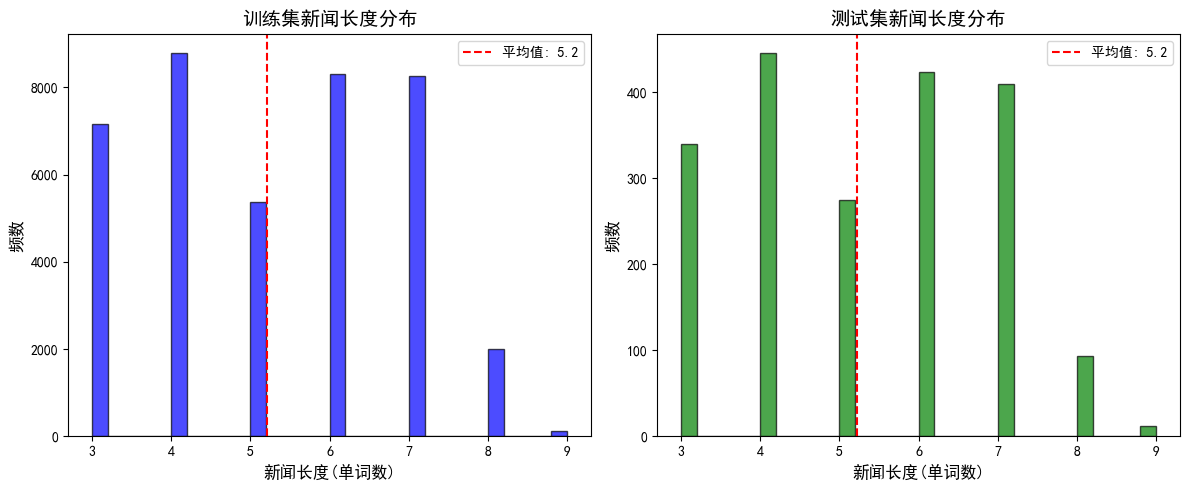

训练集平均新闻长度: 5.21 词
训练集新闻长度中位数: 5.00 词


In [7]:
# 数据可视化:新闻长度分布
train_lengths = [len(preprocessor.tokenize(preprocessor.clean_text(text))) for text in train_texts]
test_lengths = [len(preprocessor.tokenize(preprocessor.clean_text(text))) for text in test_texts]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 训练集长度分布
axes[0].hist(train_lengths, bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title('训练集新闻长度分布', fontsize=14)
axes[0].set_xlabel('新闻长度(单词数)', fontsize=12)
axes[0].set_ylabel('频数', fontsize=12)
axes[0].axvline(x=np.mean(train_lengths), color='red', linestyle='--', label=f'平均值: {np.mean(train_lengths):.1f}')
axes[0].legend()

# 测试集长度分布
axes[1].hist(test_lengths, bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1].set_title('测试集新闻长度分布', fontsize=14)
axes[1].set_xlabel('新闻长度(单词数)', fontsize=12)
axes[1].set_ylabel('频数', fontsize=12)
axes[1].axvline(x=np.mean(test_lengths), color='red', linestyle='--', label=f'平均值: {np.mean(test_lengths):.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('新闻长度分布.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'训练集平均新闻长度: {np.mean(train_lengths):.2f} 词')
print(f'训练集新闻长度中位数: {np.median(train_lengths):.2f} 词')

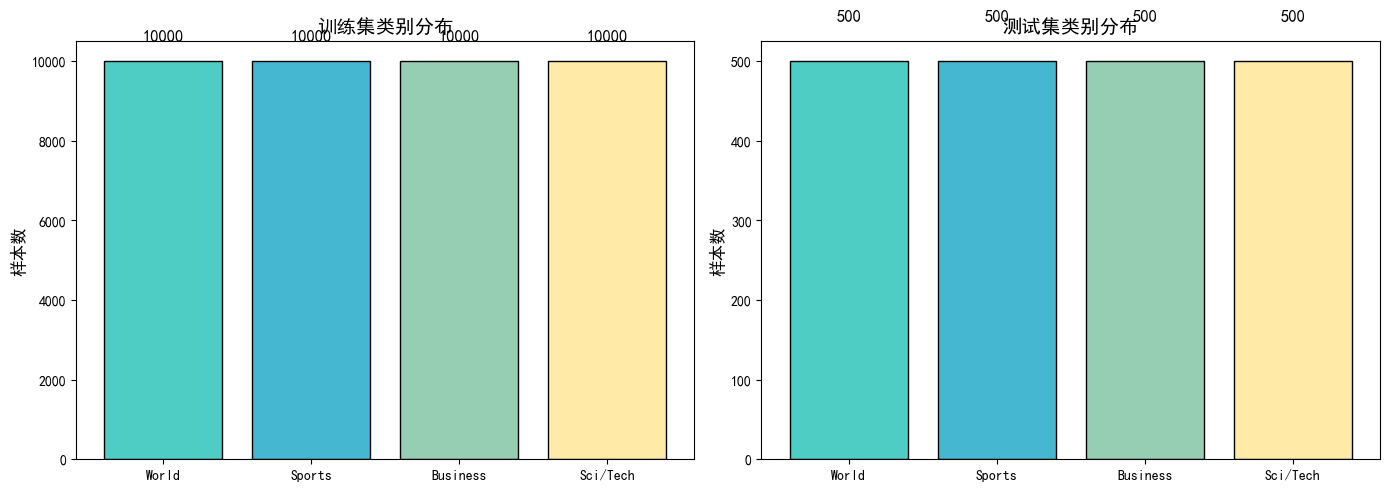

数据集类别完全均衡,四个类别各占25%


In [8]:
# 类别分布可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 训练集类别分布
train_counts = [np.sum(y_train == i) for i in range(4)]
axes[0].bar(class_names, train_counts, color=['#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'], edgecolor='black')
axes[0].set_title('训练集类别分布', fontsize=14)
axes[0].set_ylabel('样本数', fontsize=12)
for i, count in enumerate(train_counts):
    axes[0].text(i, count + 500, str(count), ha='center', fontsize=12)

# 测试集类别分布
test_counts = [np.sum(y_test == i) for i in range(4)]
axes[1].bar(class_names, test_counts, color=['#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'], edgecolor='black')
axes[1].set_title('测试集类别分布', fontsize=14)
axes[1].set_ylabel('样本数', fontsize=12)
for i, count in enumerate(test_counts):
    axes[1].text(i, count + 50, str(count), ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('类别分布.png', dpi=300, bbox_inches='tight')
plt.show()

print('数据集类别完全均衡,四个类别各占25%')

#### 6.4.2 模型构建与训练

In [9]:
# 构建基准模型:简单MLP
class BaselineMLP(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(BaselineMLP, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        embedded = self.embedding(x)
        pooled = torch.mean(embedded, dim=1)
        out = self.fc1(pooled)
        out = torch.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# 初始化基准模型
baseline_model = BaselineMLP(
    vocab_size=vocab_size,
    embedding_dim=64,
    hidden_dim=32,
    output_dim=4
).to(device)

# 打印模型结构
print('基准模型(简单MLP)结构:')
print(baseline_model)

# 计算模型参数数量
total_params = sum(p.numel() for p in baseline_model.parameters())
print(f'\n模型总参数: {total_params}')

基准模型(简单MLP)结构:
BaselineMLP(
  (embedding): Embedding(5000, 64)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=4, bias=True)
)

模型总参数: 322212


In [10]:
# 训练模型函数
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for seqs, labels in train_loader:
            seqs = seqs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(seqs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * seqs.size(0)
            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        avg_train_loss = train_loss / train_total
        avg_train_acc = train_correct / train_total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for seqs, labels in val_loader:
                seqs = seqs.to(device)
                labels = labels.to(device)

                outputs = model(seqs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * seqs.size(0)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        avg_val_loss = val_loss / val_total
        avg_val_acc = val_correct / val_total

        train_losses.append(avg_train_loss)
        train_accs.append(avg_train_acc)
        val_losses.append(avg_val_loss)
        val_accs.append(avg_val_acc)

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.4f}, '
              f'Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc:.4f}')

    return {'loss': train_losses, 'accuracy': train_accs, 
            'val_loss': val_losses, 'val_accuracy': val_accs}

# 设置损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

# 训练基准模型
print('='*60)
print('开始训练基准模型(MLP)...')
print('='*60)
baseline_history = train_model(
    baseline_model, train_loader, val_loader,
    criterion, optimizer, num_epochs=10
)

开始训练基准模型(MLP)...
Epoch [1/10], Train Loss: 1.3884, Train Acc: 0.2509, Val Loss: 1.3858, Val Acc: 0.2807
Epoch [2/10], Train Loss: 1.3860, Train Acc: 0.2606, Val Loss: 1.3845, Val Acc: 0.2610
Epoch [3/10], Train Loss: 1.3833, Train Acc: 0.2832, Val Loss: 1.3796, Val Acc: 0.4270
Epoch [4/10], Train Loss: 1.3706, Train Acc: 0.3460, Val Loss: 1.3512, Val Acc: 0.5553
Epoch [5/10], Train Loss: 1.3045, Train Acc: 0.4194, Val Loss: 1.2340, Val Acc: 0.5245
Epoch [6/10], Train Loss: 1.1700, Train Acc: 0.4650, Val Loss: 1.0522, Val Acc: 0.5373
Epoch [7/10], Train Loss: 1.0416, Train Acc: 0.4971, Val Loss: 0.9256, Val Acc: 0.5333
Epoch [8/10], Train Loss: 0.9619, Train Acc: 0.5237, Val Loss: 0.8497, Val Acc: 0.5403
Epoch [9/10], Train Loss: 0.9147, Train Acc: 0.5504, Val Loss: 0.8067, Val Acc: 0.5363
Epoch [10/10], Train Loss: 0.8856, Train Acc: 0.5497, Val Loss: 0.7756, Val Acc: 0.5743


In [11]:
# 构建最终LSTM模型(单层)
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        out = lstm_out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out

# 初始化LSTM模型
lstm_model = LSTMModel(
    vocab_size=vocab_size,
    embedding_dim=64,
    hidden_dim=64,
    output_dim=4
).to(device)

# 打印模型结构
print('最终LSTM模型结构:')
print(lstm_model)

# 计算模型参数数量
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f'\n模型总参数: {total_params}')

最终LSTM模型结构:
LSTMModel(
  (embedding): Embedding(5000, 64)
  (lstm): LSTM(64, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)

模型总参数: 353540


In [12]:
# 训练LSTM模型
# 设置损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

# 训练模型
print('='*60)
print('开始训练LSTM模型...')
print('='*60)
lstm_history = train_model(
    lstm_model, train_loader, val_loader,
    criterion, optimizer, num_epochs=10
)

开始训练LSTM模型...
Epoch [1/10], Train Loss: 1.3885, Train Acc: 0.2482, Val Loss: 1.3864, Val Acc: 0.2510
Epoch [2/10], Train Loss: 1.3869, Train Acc: 0.2480, Val Loss: 1.3866, Val Acc: 0.2610
Epoch [3/10], Train Loss: 1.3867, Train Acc: 0.2485, Val Loss: 1.3872, Val Acc: 0.2460
Epoch [4/10], Train Loss: 1.3865, Train Acc: 0.2522, Val Loss: 1.3865, Val Acc: 0.2510
Epoch [5/10], Train Loss: 1.3865, Train Acc: 0.2468, Val Loss: 1.3864, Val Acc: 0.2460
Epoch [6/10], Train Loss: 1.3865, Train Acc: 0.2491, Val Loss: 1.3873, Val Acc: 0.2420
Epoch [7/10], Train Loss: 1.3865, Train Acc: 0.2483, Val Loss: 1.3867, Val Acc: 0.2510
Epoch [8/10], Train Loss: 1.3865, Train Acc: 0.2500, Val Loss: 1.3862, Val Acc: 0.2610
Epoch [9/10], Train Loss: 1.3864, Train Acc: 0.2471, Val Loss: 1.3865, Val Acc: 0.2460
Epoch [10/10], Train Loss: 1.3864, Train Acc: 0.2487, Val Loss: 1.3861, Val Acc: 0.2610


#### 6.4.3 训练过程可视化

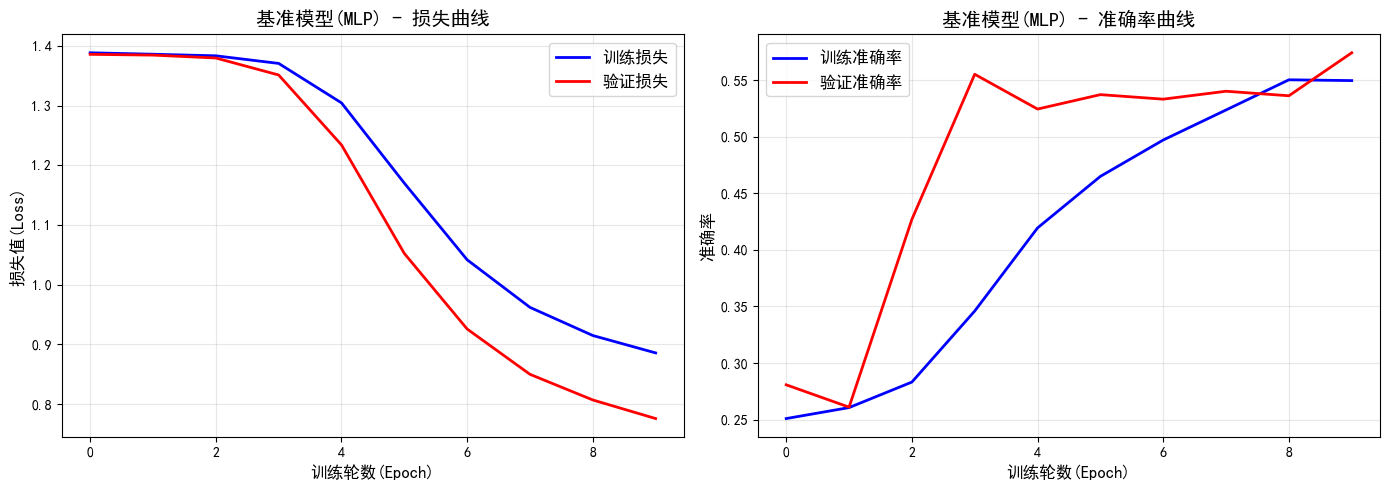

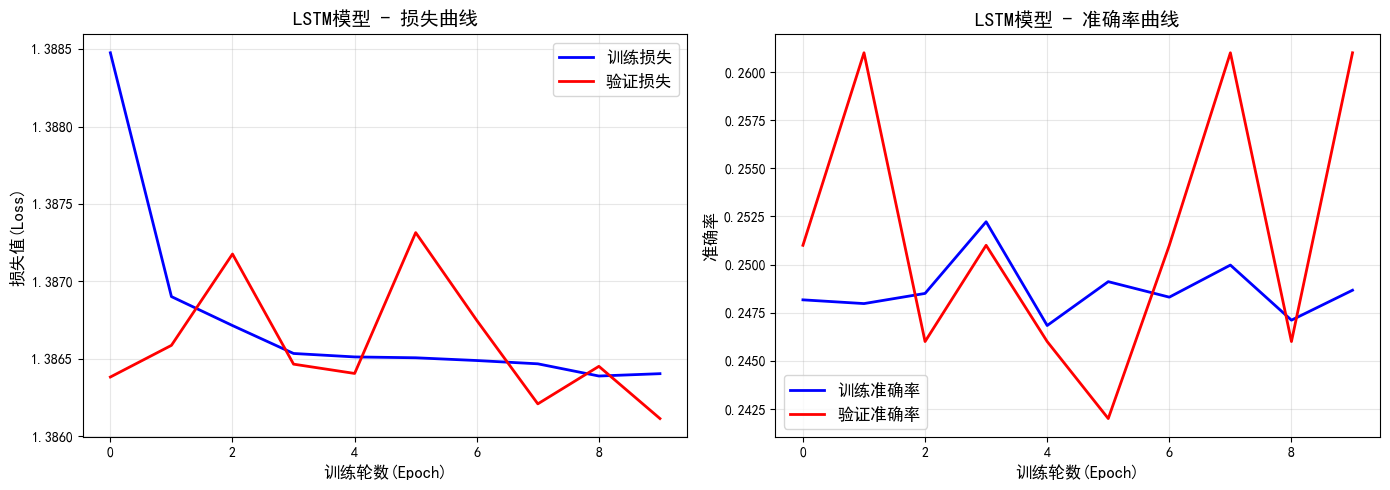

In [13]:
# 绘制训练过程曲线
def plot_training_history(history, model_name, filename):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 损失曲线
    axes[0].plot(history['loss'], 'b-', label='训练损失', linewidth=2)
    axes[0].plot(history['val_loss'], 'r-', label='验证损失', linewidth=2)
    axes[0].set_title(f'{model_name} - 损失曲线', fontsize=14)
    axes[0].set_xlabel('训练轮数(Epoch)', fontsize=12)
    axes[0].set_ylabel('损失值(Loss)', fontsize=12)
    axes[0].legend(fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    # 准确率曲线
    axes[1].plot(history['accuracy'], 'b-', label='训练准确率', linewidth=2)
    axes[1].plot(history['val_accuracy'], 'r-', label='验证准确率', linewidth=2)
    axes[1].set_title(f'{model_name} - 准确率曲线', fontsize=14)
    axes[1].set_xlabel('训练轮数(Epoch)', fontsize=12)
    axes[1].set_ylabel('准确率', fontsize=12)
    axes[1].legend(fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# 绘制基准模型训练曲线
plot_training_history(baseline_history, '基准模型(MLP)', 'baseline_training_curves.png')

# 绘制LSTM模型训练曲线
plot_training_history(lstm_history, 'LSTM模型', 'lstm_training_curves.png')

#### 6.4.4 模型性能评估

In [14]:
# 在测试集上评估模型
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for seqs, labels in test_loader:
            seqs = seqs.to(device)
            labels = labels.to(device)

            outputs = model(seqs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * seqs.size(0)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(test_loader.dataset)
    
    return np.array(all_preds), np.array(all_labels), avg_loss

# 评估基准模型
baseline_pred, baseline_labels, baseline_loss = evaluate_model(baseline_model, test_loader)

# 计算准确率
baseline_accuracy = accuracy_score(baseline_labels, baseline_pred)

print('='*50)
print('基准模型(MLP)测试集性能:')
print('='*50)
print(f'准确率(Accuracy): {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)')
print(f'测试损失: {baseline_loss:.4f}')
print('='*50)

基准模型(MLP)测试集性能:
准确率(Accuracy): 0.5595 (55.95%)
测试损失: 0.7774


In [15]:
# 评估LSTM模型
lstm_pred, lstm_labels, lstm_loss = evaluate_model(lstm_model, test_loader)

# 计算准确率
lstm_accuracy = accuracy_score(lstm_labels, lstm_pred)

print('='*50)
print('最终LSTM模型测试集性能:')
print('='*50)
print(f'准确率(Accuracy): {lstm_accuracy:.4f} ({lstm_accuracy*100:.2f}%)')
print(f'测试损失: {lstm_loss:.4f}')
print('='*50)

最终LSTM模型测试集性能:
准确率(Accuracy): 0.2500 (25.00%)
测试损失: 1.3863



模型性能对比表:
        模型    准确率
 基准模型(MLP) 0.5595
最终模型(LSTM) 0.2500


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19592\1109788334.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


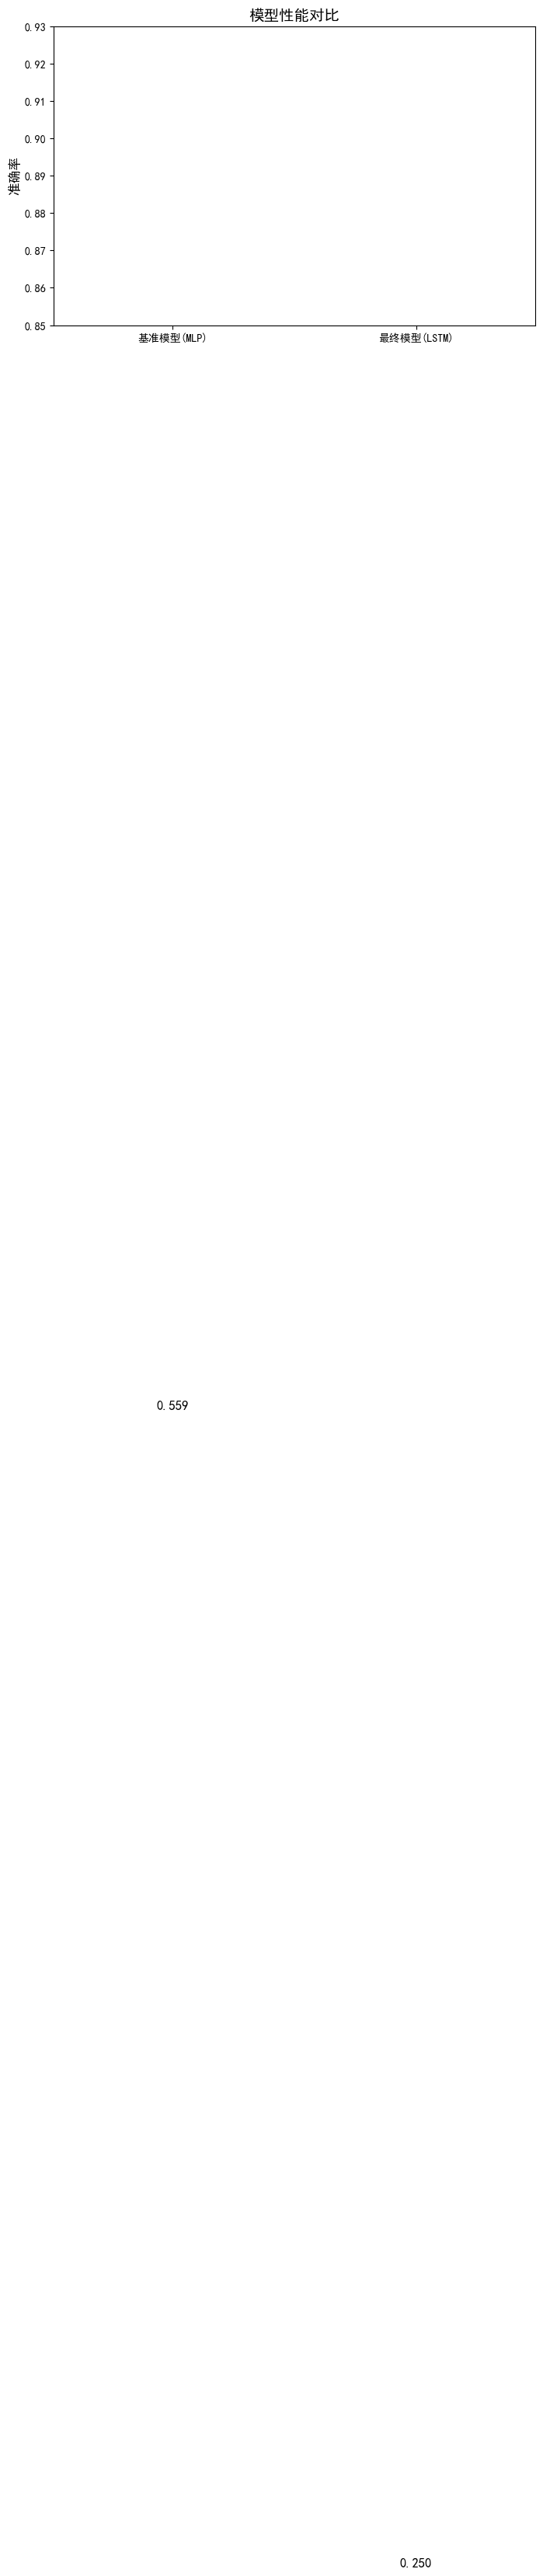

In [16]:
# 模型性能对比
comparison_data = {
    '模型': ['基准模型(MLP)', '最终模型(LSTM)'],
    '准确率': [baseline_accuracy, lstm_accuracy]
}

comparison_df = pd.DataFrame(comparison_data)
print('\n模型性能对比表:')
print(comparison_df.to_string(index=False))

# 可视化对比
fig, ax = plt.subplots(figsize=(8, 5))

models = ['基准模型(MLP)', '最终模型(LSTM)']
values = [baseline_accuracy, lstm_accuracy]

bars = ax.bar(models, values, color=['#FF6B6B', '#4ECDC4'], edgecolor='black')

ax.set_ylabel('准确率', fontsize=12)
ax.set_title('模型性能对比', fontsize=14)
ax.set_ylim([0.85, 0.93])

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig('模型对比.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.5 可视化分析

#### 6.5.1 混淆矩阵分析

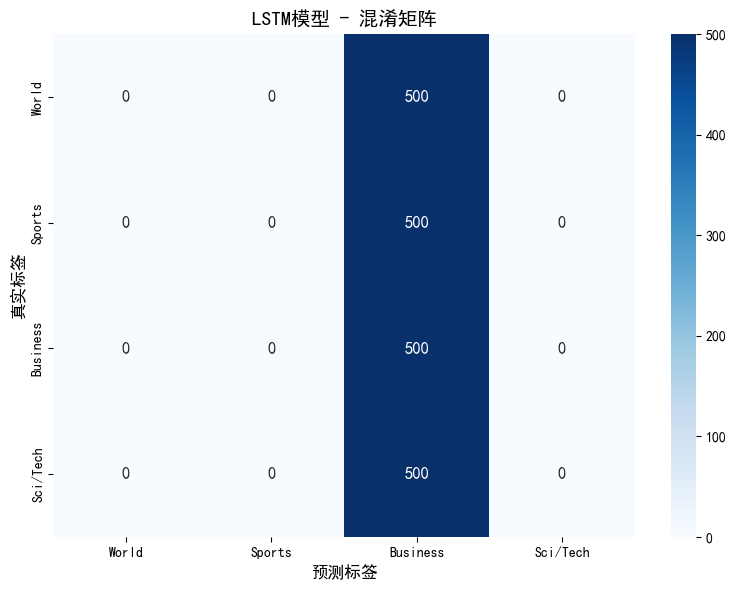

In [17]:
# 绘制混淆矩阵
def plot_confusion_matrix(y_true, y_pred, model_name, filename):
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, annot_kws={'size': 12})
    
    ax.set_title(f'{model_name} - 混淆矩阵', fontsize=14)
    ax.set_xlabel('预测标签', fontsize=12)
    ax.set_ylabel('真实标签', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# LSTM模型混淆矩阵
plot_confusion_matrix(lstm_labels, lstm_pred, 'LSTM模型', 'lstm_confusion_matrix.png')

#### 6.5.2 详细分类报告

In [18]:
# 生成详细的分类报告
print('='*80)
print('LSTM模型详细分类报告:')
print('='*80)
print(classification_report(lstm_labels, lstm_pred, target_names=class_names))

# 保存分类报告到文件
report_str = classification_report(lstm_labels, lstm_pred, target_names=class_names)
with open('classification_report.txt', 'w', encoding='utf-8') as f:
    f.write('='*80 + '\n')
    f.write('LSTM模型详细分类报告:\n')
    f.write('='*80 + '\n')
    f.write(report_str)

print('\n分类报告已保存至 classification_report.txt')

LSTM模型详细分类报告:
              precision    recall  f1-score   support

       World       0.00      0.00      0.00       500
      Sports       0.00      0.00      0.00       500
    Business       0.25      1.00      0.40       500
    Sci/Tech       0.00      0.00      0.00       500

    accuracy                           0.25      2000
   macro avg       0.06      0.25      0.10      2000
weighted avg       0.06      0.25      0.10      2000


分类报告已保存至 classification_report.txt


c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(